<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Predict Stabilizing Variants via Deep Mutational Scan

While ESM2 has similar performance to ESM-1v, the latter is still a great option for performing an _in silico_ deep mutational scan. ESM-1v is a collection of five models, trained on sequences from UniRef, each with different seeds. Ensembling these five models' scores can produce better results than a single ESM-1v model, for such broad topics like identifying stabilizing mutations.

Since these models were _only_ trained on functional molecules, they are capable of assessing whether a new molecule might also be functional, or whether it has a disastrous mutation.

Imagine only learning and speaking English your whole life - could you identify whether a new English word is English? Probably. What about whether a Korean word is Korean? Or whether a French word is French? You might not be able to identify a Korean word as *specifically* Korean since you were only exposed to English; but you can tell that some foreign words are at least *not-English*. The idea is similar with this zero-shot model, ESM-1v: how likely is a sequence *functional*, since the model was only exposed to functional sequences.

We do this by masking each position and requesting the scores for each residue at that position. For a sequence of even a couple hundred residues, this is thousands of predictions from each of the 5 GPU-based models. [BioLM has APIs](https://api.biolm.ai/#67f77d96-c4d8-4a1f-953a-d26330c27315) to get these results at scale much faster than it would take to spin up these models on multiple GPUs alone.

In [33]:
import time
from biolmai import BioLM
from IPython.display import JSON  # Helpful UI for JSON display
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Let's use the sequence from the paper
# https://www.biorxiv.org/content/10.1101/2021.07.09.450648v2.full.pdf
WILDTYPE = "ASKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKRHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

print("Sequence length: {}".format(len(WILDTYPE)))

Sequence length: 238


We can copy working Python code for making a request to BioLM.ai's ESM-1v API:

In [23]:
def esm1v_pred(seq):
    """Get un-masking predictions from any of the 5 ESM-1v models via REST API.
    
    From API docs: https://api.biolm.ai/#54d3367a-b5d1-4f18-aa44-23ae3914a446
    """
    assert '<mask>' in seq

    response = BioLM(entity=f"esm1v-all", action="predict", type="sequence", items=[seq])


    return response

Now test our function on the first residue and first model.

In [9]:
result = esm1v_pred('<mask>' + WILDTYPE[1:])  # First ESM-1v model
JSON(result)

<IPython.core.display.JSON object>

We can see that `"M"`, or Methionine is the most likely starting AA. Methionine is a common starting AA amongst many organisms. 

Next, We can examine predictions from the other ESM-1v models, then ensemble the likelihood scores for best results.

In [12]:
JSON(result["esm1v-n2"])

<IPython.core.display.JSON object>

You can observe the probabilities for each token (amino acid residue) differing between the two models.

Loading the data into a DF is simple.

In [14]:
pd.DataFrame.from_dict(result["esm1v-n2"], orient='columns')

,token,token_str,score,sequence
0,20,M,0.945713,M S K G E E L F T G V V P I L V E L D G D V N ...
1,4,L,0.004731,L S K G E E L F T G V V P I L V E L D G D V N ...
2,6,G,0.004624,G S K G E E L F T G V V P I L V E L D G D V N ...
3,8,S,0.004320,S S K G E E L F T G V V P I L V E L D G D V N ...
4,15,K,0.003869,K S K G E E L F T G V V P I L V E L D G D V N ...
5,7,V,0.003802,V S K G E E L F T G V V P I L V E L D G D V N ...
6,12,I,0.003527,I S K G E E L F T G V V P I L V E L D G D V N ...
7,5,A,0.003489,A S K G E E L F T G V V P I L V E L D G D V N ...
8,9,E,0.003188,E S K G E E L F T G V V P I L V E L D G D V N ...
9,11,T,0.003166,T S K G E E L F T G V V P I L V E L D G D V N ...


Let's scan the whole sequence now, using several of the five ESM-1v models. This should be fairly fast sequentially. Let's simply loop through each model and position. To ensemble and average predictions from all five models, we use the [ESM-1v all](https://api.biolm.ai/#67f77d96-c4d8-4a1f-953a-d26330c27315) endpoint which does this directly.

In [24]:
import copy

results = []

def f(idx, seq):
    if idx % 20 == 0:
        print("Submitting twenty positions from {}/{} with ESM-1v Model".format(idx, len(seq)))
    # Mask that position
    seq_masked = list(copy.copy(seq))
    seq_masked[idx] = '<mask>'
    seq_masked = ''.join(seq_masked)
    r = esm1v_pred(seq_masked)
    # Request the probabilities of each AA at that mask

    for mdl in range(1, 6):
        r_df = pd.DataFrame.from_dict(r[f"esm1v-n{mdl}"], orient='columns')
        r_df['model_num'] = mdl
        r_df['mask_pos'] = idx
        results.append(r_df)


ops = [f(i, WILDTYPE) for i in range(len(WILDTYPE))]


Submitting twenty positions from 0/238 with ESM-1v Model
Submitting twenty positions from 20/238 with ESM-1v Model
Submitting twenty positions from 40/238 with ESM-1v Model
Submitting twenty positions from 60/238 with ESM-1v Model
Submitting twenty positions from 80/238 with ESM-1v Model
Submitting twenty positions from 100/238 with ESM-1v Model
Submitting twenty positions from 120/238 with ESM-1v Model
Submitting twenty positions from 140/238 with ESM-1v Model
Submitting twenty positions from 160/238 with ESM-1v Model
Submitting twenty positions from 180/238 with ESM-1v Model
Submitting twenty positions from 200/238 with ESM-1v Model
Submitting twenty positions from 220/238 with ESM-1v Model


In [25]:
results[0]  # Look at the first result DF we made

,token,token_str,score,sequence,model_num,mask_pos
0,20,M,0.909230,M S K G E E L F T G V V P I L V E L D G D V N ...,1,0
1,4,L,0.008935,L S K G E E L F T G V V P I L V E L D G D V N ...,1,0
2,7,V,0.007254,V S K G E E L F T G V V P I L V E L D G D V N ...,1,0
3,6,G,0.007158,G S K G E E L F T G V V P I L V E L D G D V N ...,1,0
4,12,I,0.006674,I S K G E E L F T G V V P I L V E L D G D V N ...,1,0
5,8,S,0.006055,S S K G E E L F T G V V P I L V E L D G D V N ...,1,0
6,15,K,0.005998,K S K G E E L F T G V V P I L V E L D G D V N ...,1,0
7,11,T,0.005336,T S K G E E L F T G V V P I L V E L D G D V N ...,1,0
8,5,A,0.005292,A S K G E E L F T G V V P I L V E L D G D V N ...,1,0
9,18,F,0.005089,F S K G E E L F T G V V P I L V E L D G D V N ...,1,0


Concatenate the resulting DFs together.

In [26]:
results_df = pd.concat(results, axis=0)

results_df.shape

(23800, 6)

In [27]:
results_df.sample(5)  # Sample some of the results to get a preview

,token,token_str,score,sequence,model_num,mask_pos
10,11,T,0.046366,A S K G E E L F T G V V P I L V E L D G D V N ...,5,170
4,18,F,0.058498,A S K G E E L F T G V V P I L V E L D G D V N ...,1,118
17,21,H,0.023180,A S K G E E L F T G V V P I L V E L D G D V N ...,1,190
14,10,R,0.037609,A S K G E E L F T G V V P I L V E L D G D V N ...,4,195
5,14,P,0.063381,A S K G E E L F T G V V P I L V E L D G D V N ...,5,210


Let's quickly fill in the WT character for each row so we can plot the results.

In [28]:
results_df['wt_token_str'] = results_df.mask_pos.apply(lambda x: WILDTYPE[x])

results_df.sample(3)

,token,token_str,score,sequence,model_num,mask_pos,wt_token_str
19,23,C,0.006759,A S K G E E L F T G V V P I L V E L D G D V N ...,5,127,I
13,5,A,0.032198,A S K G E E L F T G V V P I L V E L D G D V N ...,5,98,F
2,18,F,0.091468,A S K G E E L F T G V V P I L V E L D G D V N ...,2,87,M


Lastly, make a DF displaying a heatmap of the most probable stabilizing variants from the above _in silico_ deep mutational scan.

In [29]:
heatmap_df = []  # Each row represents the full sequence, with a single token_str at each position

for residue in results_df.token_str.drop_duplicates().to_list():
    tmp_row = []
    for pos in range(len(WILDTYPE)):
        token_position_score = results_df.query('token_str == @residue & mask_pos == @pos').score.iloc[0]
        tmp_row.append(token_position_score)
    heatmap_df.append(tmp_row)

In [30]:
heatmap_df = pd.DataFrame(heatmap_df)

heatmap_df.shape

(20, 238)

In [31]:
heatmap_df.head(1).iloc[0][0]

0.9092302918434143

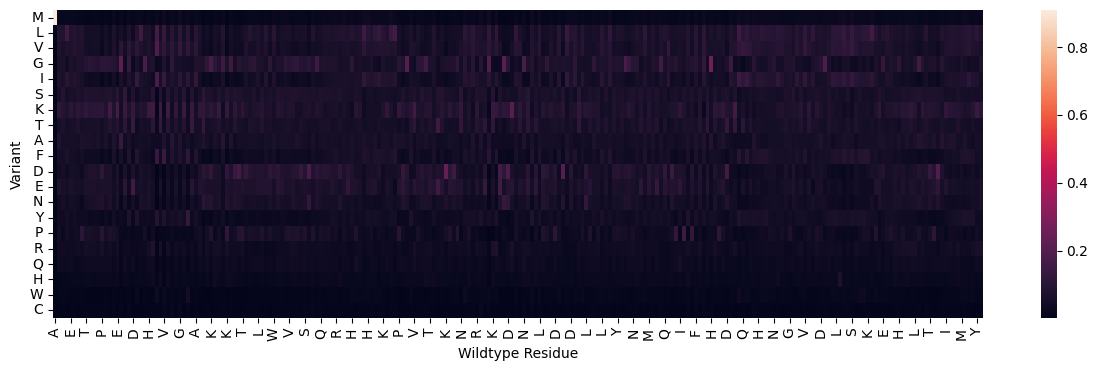

In [34]:


fig = plt.figure(figsize=[15, 4])

ax = sns.heatmap(heatmap_df)
_ = ax.set_xticklabels(list(WILDTYPE)[::int(len(WILDTYPE)/50)])
_ = ax.set_yticklabels(results_df.token_str.drop_duplicates())
_ = ax.set(xlabel='Wildtype Residue', ylabel='Variant')

This is a quick depiciton of the results. What you want to look for in the DF is mutations where the score is greater than the score of the wild-type residue at the same location. These can be extracted with some quick slicing of `results_df`, which we'll leave up to you to explore. There appear to be several mutations with greater likelihood that the wild-type sequence.

## Next Steps

Check out additional tutorials at [jupyter.biolm.ai](https://jupyter.biolm.ai),
or head over to our [BioLM Documentation](https://docs.biolm.ai) to explore
additional models and functionality.

#### See more use-cases and APIs on your [BioLM Console Catalog](https://biolm.ai/console/catalog/).
<br>

##### BioLM hosts deep learning models and runs inference at scale. You do the science.
<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/enzyme_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Enzyme Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/antibody_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Antibody Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/biosecurity_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Biosecurity
        </td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/single_cell_genomics_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Single-Cell Genomics
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/dna_seq_modeling_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> DNA Sequence Modelling
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/finetuning_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Finetuning
        </td>
    </tr>
</table>

#### [**Contact us**](https://biolm.ai/ui/contact-us/) to learn more.
